# GRU Model - Phishing Website Detection

This notebook implements and evaluates the Gated Recurrent Unit (GRU) architecture using the common preprocessed dataset and evaluation procedure used by the project.

## 1. Import Required Libraries

This section imports the libraries needed for data handling, model building, training, visualization, and performance evaluation.

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import time
import os

from tensorflow.keras import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

## 2. Load Preprocessed Dataset

The preprocessed training, validation, and test datasets are loaded from NumPy `.npy` files. Each input sample contains 50 numerical features.

In [2]:
import numpy as np
import os

DATA_DIR = "../data/processed"

X_train = np.load(os.path.join(DATA_DIR, "X_train.npy"))
y_train = np.load(os.path.join(DATA_DIR, "y_train.npy"))

X_val = np.load(os.path.join(DATA_DIR, "X_val.npy"))
y_val = np.load(os.path.join(DATA_DIR, "y_val.npy"))

X_test = np.load(os.path.join(DATA_DIR, "X_test.npy"))
y_test = np.load(os.path.join(DATA_DIR, "y_test.npy"))

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (165056, 50)
y_train: (165056,)
X_val: (35369, 50)
y_val: (35369,)
X_test: (35370, 50)
y_test: (35370,)


## 3. Reshape Data for GRU Input

GRU layers require 3D input in the form `(samples, timesteps, features)`. The 50-feature vectors are reshaped to `(samples, 50, 1)`.

In [3]:
X_train_gru = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val_gru = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test_gru = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("GRU input shapes:")
print("X_train_gru:", X_train_gru.shape)
print("X_val_gru:", X_val_gru.shape)
print("X_test_gru:", X_test_gru.shape)

GRU input shapes:
X_train_gru: (165056, 50, 1)
X_val_gru: (35369, 50, 1)
X_test_gru: (35370, 50, 1)


## 4. Build GRU Model

The model uses a 64-unit GRU layer to process the feature sequence, followed by dropout and dense layers. A sigmoid output neuron produces the final binary classification probability.

In [5]:
tf.keras.utils.set_random_seed(42)

model = Sequential([
    tf.keras.Input(shape=(50, 1)),
    GRU(64),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,977 (58.50 KB)

 Trainable params: 14,977 (58.50 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Compile Model and Configure Early Stopping

The model is compiled using the Adam optimizer and binary cross-entropy loss. Early stopping monitors validation loss and restores the best model weights.

In [6]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

print("Model compiled successfully.")

Model compiled successfully.


## 6. Train the GRU Model

The GRU model is trained using the training set while validation performance is monitored after each epoch. Early stopping helps reduce unnecessary training and overfitting.

In [7]:
start_time = time.time()

history = model.fit(
    X_train_gru,
    y_train,
    validation_data=(X_val_gru, y_val),
    epochs=50,
    batch_size=256,
    callbacks=[early_stopping],
    verbose=1
)

training_time = time.time() - start_time

print(f"Training completed in {training_time:.2f} seconds")

Epoch 1/50
645/645 ━━━━━━━━━━━━━━━━━━━━ 63s 92ms/step - accuracy: 0.9636 - loss: 0.1053 - val_accuracy: 0.9899 - val_loss: 0.0304
Epoch 2/50
645/645 ━━━━━━━━━━━━━━━━━━━━ 77s 119ms/step - accuracy: 0.9916 - loss: 0.0251 - val_accuracy: 0.9931 - val_loss: 0.0210
Epoch 3/50
645/645 ━━━━━━━━━━━━━━━━━━━━ 75s 116ms/step - accuracy: 0.9944 - loss: 0.0176 - val_accuracy: 0.9943 - val_loss: 0.0170
Epoch 4/50
645/645 ━━━━━━━━━━━━━━━━━━━━ 74s 115ms/step - accuracy: 0.9962 - loss: 0.0119 - val_accuracy: 0.9976 - val_loss: 0.0072
Epoch 5/50
645/645 ━━━━━━━━━━━━━━━━━━━━ 64s 99ms/step - accuracy: 0.9976 - loss: 0.0078 - val_accuracy: 0.9984 - val_loss: 0.0048
Epoch 6/50
645/645 ━━━━━━━━━━━━━━━━━━━━ 56s 86ms/step - accuracy: 0.9983 - loss: 0.0059 - val_accuracy: 0.9989 - val_loss: 0.0041
Epoch 7/50
645/645 ━━━━━━━━━━━━━━━━━━━━ 55s 85ms/step - accuracy: 0.9986 - loss: 0.0049 - val_accuracy: 0.9988 - val_loss: 0.0041
Epoch 8/50
645/645 ━━━━━━━━━━━━━━━━━━━━ 59s 92ms/step - accuracy: 0.9990 - loss: 0.0038

## 7. Evaluate GRU on the Unseen Test Set

The trained GRU model is evaluated using the test set that was not used during training or validation. Predictions are converted into binary labels using a probability threshold of 0.5.

In [8]:
y_prob = model.predict(X_test_gru).ravel()
y_pred = (y_prob >= 0.5).astype(int)

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred, zero_division=0)
test_recall = recall_score(y_test, y_pred, zero_division=0)
test_f1 = f1_score(y_test, y_pred, zero_division=0)
test_roc_auc = roc_auc_score(y_test, y_prob)

print(f"Test Accuracy : {test_accuracy:.6f}")
print(f"Test Precision: {test_precision:.6f}")
print(f"Test Recall   : {test_recall:.6f}")
print(f"Test F1-score : {test_f1:.6f}")
print(f"Test ROC-AUC  : {test_roc_auc:.6f}")
print(f"Parameters    : {model.count_params():,}")
print(f"Epochs Trained: {len(history.history['loss'])}")
print(f"Training Time : {training_time:.2f} seconds")

1106/1106 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step
Test Accuracy : 0.999661
Test Precision: 0.999802
Test Recall   : 0.999605
Test F1-score : 0.999703
Test ROC-AUC  : 1.000000
Parameters    : 14,977
Epochs Trained: 27
Training Time : 1541.53 seconds


## 8. Confusion Matrix

The confusion matrix is used to inspect the number of correct and incorrect classifications made by the GRU model on the unseen test set.

In [9]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nTotal misclassified samples:", np.sum(y_test != y_pred))

Confusion Matrix:
[[15138     4]
 [    8 20220]]

Total misclassified samples: 12


## 8. Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions for phishing and legitimate websites on the unseen test set.

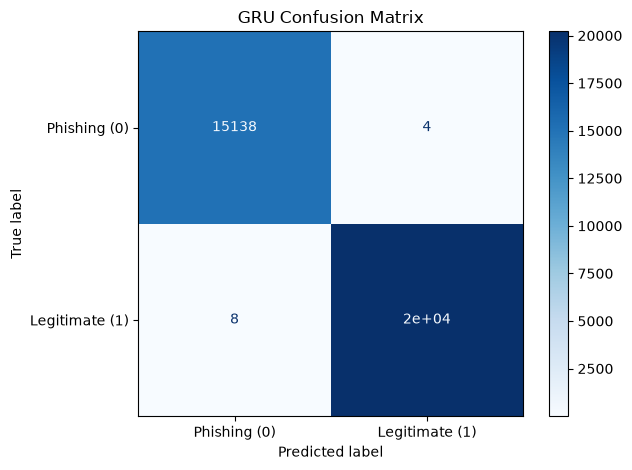

In [10]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Phishing (0)", "Legitimate (1)"]
)

disp.plot(cmap="Blues")
plt.title("GRU Confusion Matrix")
plt.tight_layout()
plt.show()

## 9. ROC Curve

The ROC curve evaluates the model's ability to distinguish between the two classes across different classification thresholds. The area under the curve (ROC-AUC) summarizes this performance.

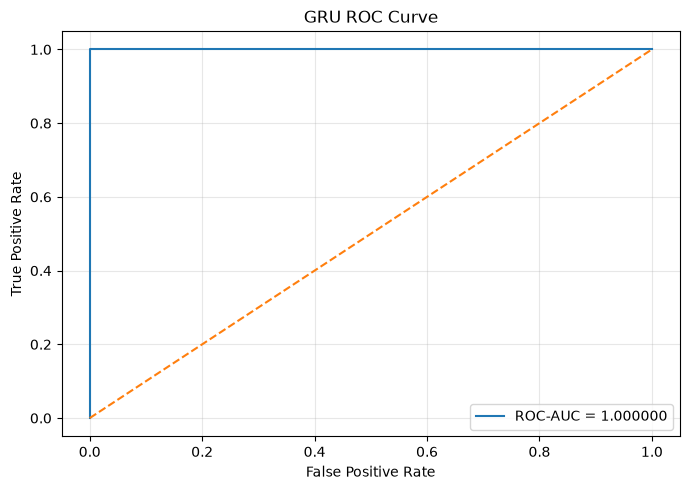

In [11]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {test_roc_auc:.6f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("GRU ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Training and Validation Curves

The training history is visualized to compare training and validation accuracy and loss across epochs. These curves help assess convergence and identify possible overfitting.

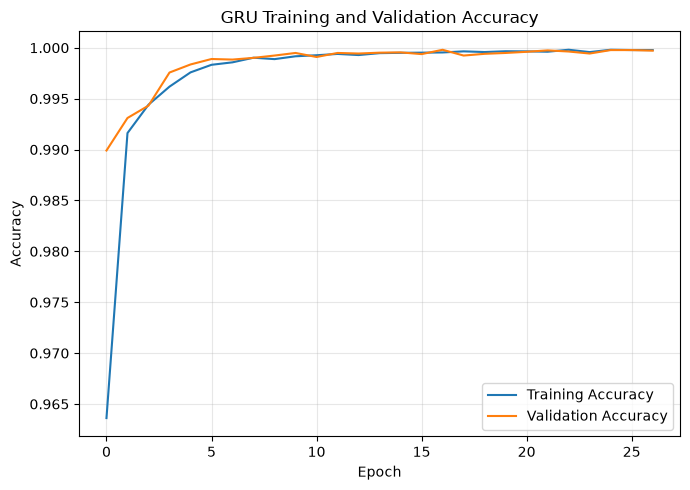

In [12]:
plt.figure(figsize=(7, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("GRU Training and Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

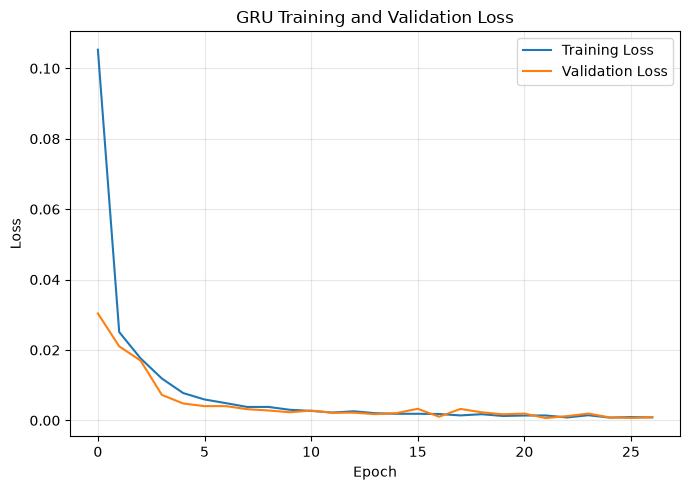

In [13]:
plt.figure(figsize=(7, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GRU Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Final GRU Results Summary

This section summarizes the final GRU architecture, training configuration, and test-set performance for comparison with the other deep-learning models in the project.

In [14]:
print("========== GRU FINAL RESULTS ==========")
print(f"Test Accuracy   : {test_accuracy:.6f}")
print(f"Test Precision  : {test_precision:.6f}")
print(f"Test Recall     : {test_recall:.6f}")
print(f"Test F1-score   : {test_f1:.6f}")
print(f"Test ROC-AUC    : {test_roc_auc:.6f}")
print(f"Total Parameters: {model.count_params():,}")
print(f"Epochs Trained  : {len(history.history['loss'])}")
print(f"Training Time   : {training_time:.2f} seconds")
print(f"Misclassifications: {np.sum(y_test != y_pred)}")
print("=======================================")

========== GRU FINAL RESULTS ==========
Test Accuracy   : 0.999661
Test Precision  : 0.999802
Test Recall     : 0.999605
Test F1-score   : 0.999703
Test ROC-AUC    : 1.000000
Total Parameters: 14,977
Epochs Trained  : 27
Training Time   : 1541.53 seconds
Misclassifications: 12
